# D1 — Language Trends & Clustering

Reads monthly language metrics and KMeans cluster assignments from GCS,
then produces:
- Top-language repo-count time-series
- Growth-rate comparison across languages
- Cluster scatter (PCA 2-D projection)
- Per-cluster member listing

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid', palette='tab10')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
monthly = pd.read_parquet(f'gs://{BUCKET}/processed/d1_monthly/')
clusters = pd.read_parquet(f'gs://{BUCKET}/processed/d1_clusters/')

monthly = monthly[monthly['year_month'] <= '2025-06']
monthly['date'] = pd.to_datetime(monthly['year_month'] + '-01')
monthly = monthly.sort_values(['language', 'date'])

print(f'Monthly rows : {len(monthly):,}')
print(f'Languages    : {monthly["language"].nunique()}')
print(f'Date range   : {monthly["date"].min().date()} → {monthly["date"].max().date()}')
print(f'Clusters rows: {len(clusters):,}')
monthly.head(3)

Monthly rows : 53,630
Languages    : 542
Date range   : 2015-01-01 → 2025-06-01
Clusters rows: 542


,language,year_month,total_bytes,repo_count,commit_count,date
12842,1c enterprise,2015-01,0,3,33,2015-01-01
16358,1c enterprise,2015-02,0,2,54,2015-02-01
11841,1c enterprise,2015-03,0,4,48,2015-03-01


## 2. Top languages by average monthly repo count

In [3]:
top_langs = (
    monthly.groupby('language')['repo_count'].mean()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)
print('Top 15 languages:', top_langs)

Top 15 languages: ['javascript', 'python', 'typescript', 'java', 'php', 'c++', 'c#', 'go', 'ruby', 'c', 'jupyter notebook', 'rust', 'vue', 'kotlin', 'swift']


## 3. Repo-count time-series — top 10 languages

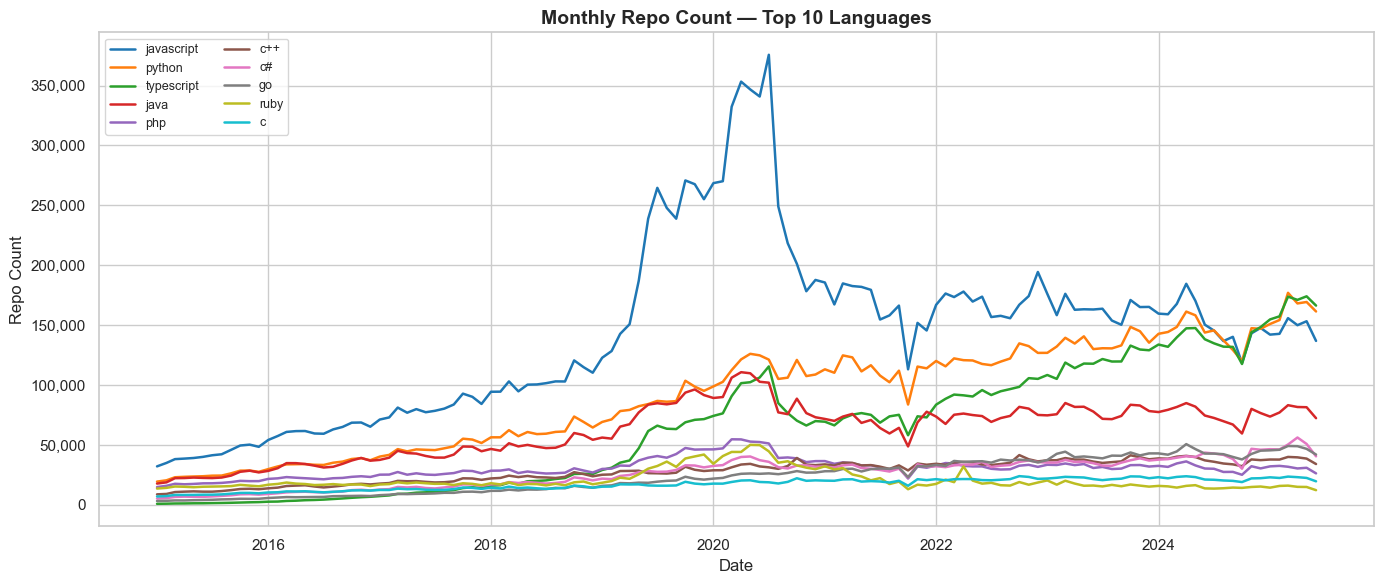

In [4]:
plot_langs = top_langs[:10]
df_plot = monthly[monthly['language'].isin(plot_langs)]

fig, ax = plt.subplots(figsize=(14, 6))
colors = cm.tab10.colors

for i, lang in enumerate(plot_langs):
    sub = df_plot[df_plot['language'] == lang]
    ax.plot(sub['date'], sub['repo_count'], label=lang,
            color=colors[i % len(colors)], linewidth=1.8)

ax.set_title('Monthly Repo Count — Top 10 Languages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Repo Count')
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/d1_timeseries.png', dpi=150)
plt.show()

## 4. Normalised growth index (repo count, base = first data point)

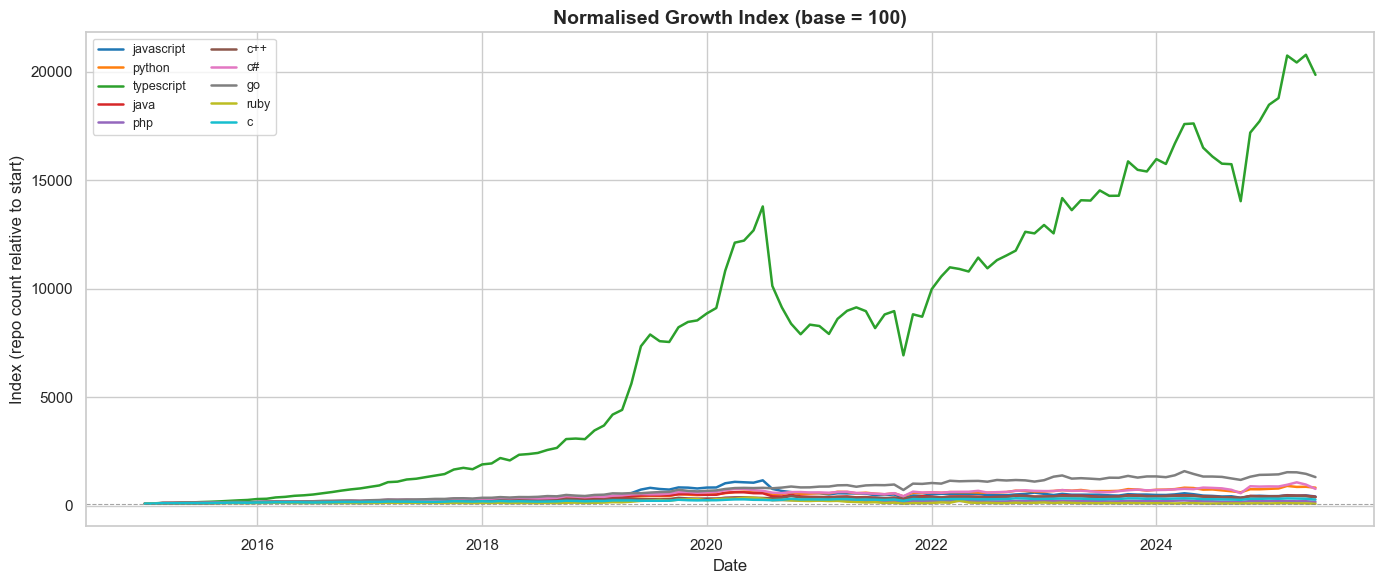

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

for i, lang in enumerate(plot_langs):
    sub = df_plot[df_plot['language'] == lang].copy()
    base = sub['repo_count'].iloc[0]
    if base > 0:
        sub['index'] = sub['repo_count'] / base * 100
        ax.plot(sub['date'], sub['index'], label=lang,
                color=colors[i % len(colors)], linewidth=1.8)

ax.axhline(100, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title('Normalised Growth Index (base = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index (repo count relative to start)')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/d1_growth_index.png', dpi=150)
plt.show()

## 5. Byte-volume comparison — top 10

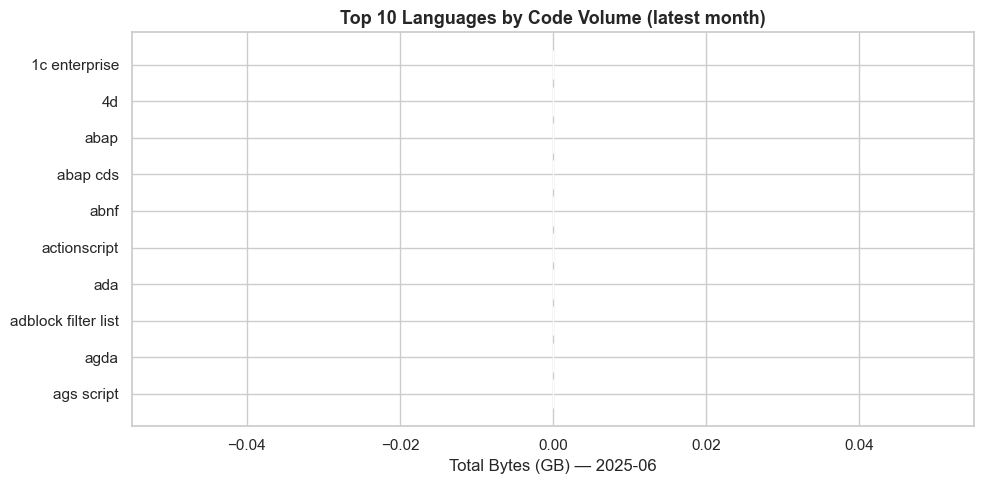

In [6]:
latest_date = monthly['date'].max()
latest = monthly[monthly['date'] == latest_date]
top10_latest = latest.nlargest(10, 'total_bytes')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10_latest['language'], top10_latest['total_bytes'] / 1e9,
               color=sns.color_palette('viridis', len(top10_latest)))
ax.set_xlabel(f'Total Bytes (GB) — {latest_date.strftime("%Y-%m")}')
ax.set_title('Top 10 Languages by Code Volume (latest month)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/d1_byte_volume.png', dpi=150)
plt.show()

## 6. KMeans cluster assignments

In [7]:
print(f'Number of clusters: {clusters["cluster"].nunique()}')
print('\nLanguages per cluster:')
for c in sorted(clusters['cluster'].unique()):
    members = clusters[clusters['cluster'] == c]['language'].sort_values().tolist()
    print(f'  Cluster {c}: {members}')

Number of clusters: 6

Languages per cluster:
  Cluster 0: ['1c enterprise', '4d', 'abap', 'abap cds', 'abnf', 'actionscript', 'ada', 'adblock filter list', 'agda', 'ags script', 'aidl', 'aiken', 'al', 'alloy', 'altium designer', 'ampl', 'angelscript', 'answer set programming', 'antlers', 'antlr', 'apacheconf', 'apex', 'api blueprint', 'apl', 'applescript', 'arc', 'arduino', 'asciidoc', 'asl', 'asp', 'asp.net', 'aspectj', 'assembly', 'astro', 'asymptote', 'ats', 'augeas', 'autohotkey', 'autoit', 'awk', 'b4x', 'ballerina', 'basic', 'beef', 'berry', 'bibtex style', 'bicep', 'bikeshed', 'bitbake', 'blade', 'blitzbasic', 'blitzmax', 'bluespec', 'boo', 'boogie', 'bqn', 'brainfuck', 'brighterscript', 'brightscript', 'bro', 'c', 'cadence', 'cairo', 'cap cds', "cap'n proto", 'cartocss', 'ceylon', 'chapel', 'charity', 'chuck', 'cil', 'circom', 'cirru', 'clarion', 'clarity', 'classic asp', 'clean', 'click', 'clips', 'clojure', 'cobol', 'codeql', 'coffeescript', 'coldfusion', 'common lisp', 'comm

## 7. PCA 2-D cluster scatter

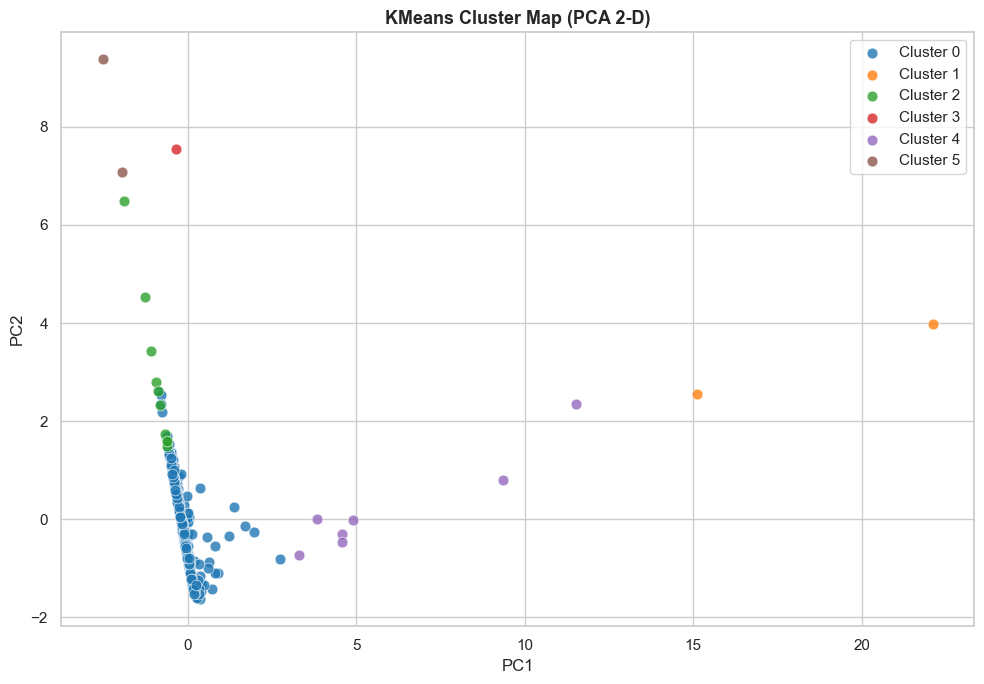

In [8]:
feature_cols = ['avg_repo_growth', 'commit_volatility', 'repo_range_ratio',
                'avg_repo_count', 'avg_commit_count']

X = clusters[feature_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)
coords = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

df_pca = clusters[['language', 'cluster']].copy()
df_pca['PC1'] = coords[:, 0]
df_pca['PC2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', clusters['cluster'].nunique())

for i, c in enumerate(sorted(df_pca['cluster'].unique())):
    sub = df_pca[df_pca['cluster'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], label=f'Cluster {c}',
               color=palette[i], s=60, alpha=0.8, edgecolors='white', linewidths=0.5)

# Label a few prominent languages
label_langs = ['Python', 'JavaScript', 'TypeScript', 'Rust', 'Go', 'Java',
               'Ruby', 'PHP', 'Kotlin', 'Swift', 'Scala', 'C++']
for _, row in df_pca[df_pca['language'].isin(label_langs)].iterrows():
    ax.annotate(row['language'], (row['PC1'], row['PC2']),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('KMeans Cluster Map (PCA 2-D)', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/d1_cluster_pca.png', dpi=150)
plt.show()

## 8. Cluster feature profiles (radar / bar)

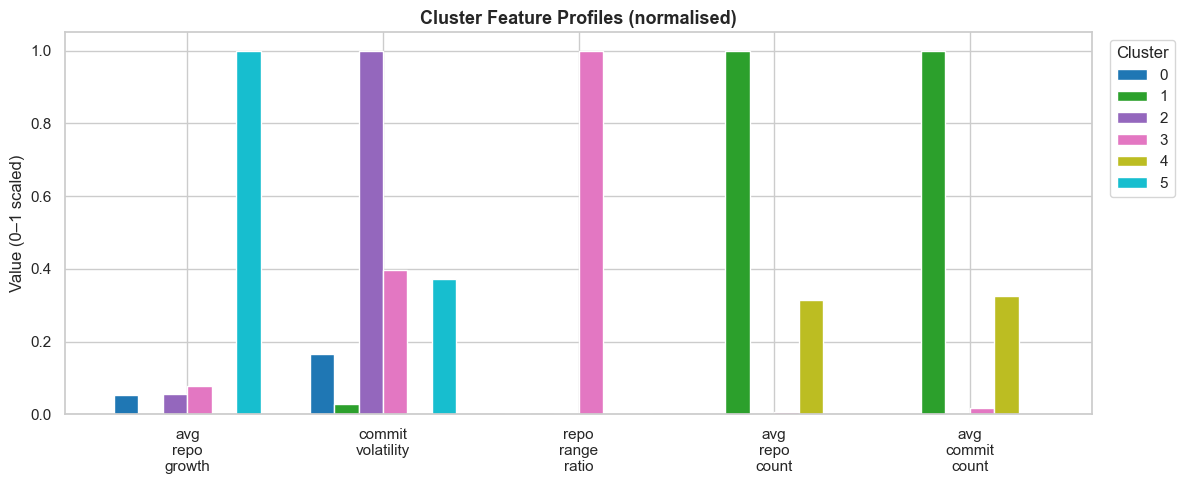

In [9]:
cluster_profiles = clusters.groupby('cluster')[feature_cols].mean()
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / \
                        (cluster_profiles.max() - cluster_profiles.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
cluster_profiles_norm.T.plot(kind='bar', ax=ax,
                              colormap='tab10', width=0.75)
ax.set_title('Cluster Feature Profiles (normalised)', fontsize=13, fontweight='bold')
ax.set_xticklabels([c.replace('_', '\n') for c in feature_cols], rotation=0)
ax.set_ylabel('Value (0–1 scaled)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/d1_cluster_profiles.png', dpi=150)
plt.show()